In [ ]:
import pandas as pd
import numpy as np
import mglearn
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.preprocessing import OneHotEncoder

X, y = mglearn.datasets.make_wave(n_samples=100)
line = np.linspace(-3, 3, 1000, endpoint=False).reshape(-1, 1)

bins = np.linspace(-3,3,11)

which_bin = np.digitize(X,bins=bins)

encoder = OneHotEncoder(sparse_output=False)
encoder.fit(which_bin)

line_binned = encoder.transform(np.digitize(line, bins=bins))
X_binned = encoder.transform(which_bin)

In [ ]:
#元の特徴量 X と、ビニングした特徴量 X_binned を横にくっつけている
X_combined = np.hstack([X, X_binned])
print("X_combined.shape:",X_combined.shape)

X_combined.shape: (100, 11)


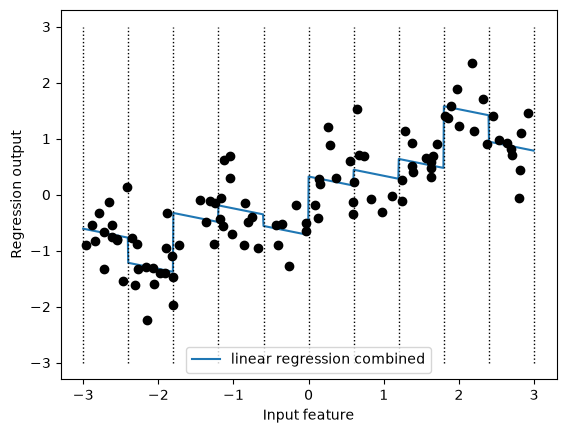

In [ ]:
from sklearn.linear_model import LinearRegression

reg = LinearRegression().fit(X_combined, y)

line_combined = np.hstack([line, line_binned])
plt.plot(line, reg.predict(line_combined), label='linear regression combined')

#y = wX + b1B1 + b2B2 + ... + b10B10
#Xが一つしかないので、傾きがすべてのビンに共通している

for bin in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k', linewidth=1)
plt.legend(loc="best")
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.plot(X[:, 0], y, 'o', c='k')
plt.show()

In [ ]:
#Xの影響が、Xがどの区間にいるかによって違うかもしれない
#ビンごとにXとビニングした特徴量の積を作ることで、ビンごとに傾きを変えることができる

X_product = np.hstack([X_binned,X * X_binned])
print("X_product.shape:",X_product.shape)

X_product.shape: (100, 20)


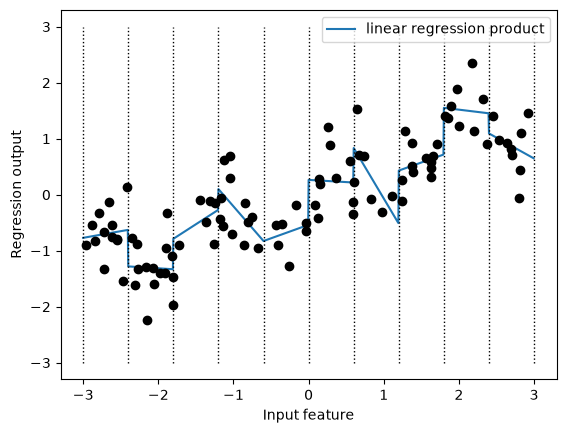

In [9]:
reg = LinearRegression().fit(X_product, y)

line_product = np.hstack([line_binned, line * line_binned])
plt.plot(line, reg.predict(line_product), label='linear regression product')

for bin in bins:
    plt.plot([bin, bin], [-3, 3], ':', c='k', linewidth=1)

plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")
plt.show()

**多項式**

In [14]:
from sklearn.preprocessing import PolynomialFeatures

#x**10までの多項式を加える
#デフォルトの"include_bias=True"だと、常に１となる特徴量を加える

poly = PolynomialFeatures(degree=10,include_bias=False)
poly.fit(X)
X_poly = poly.transform(X)

print("X_poly.shape:",X_poly.shape)


X_poly.shape: (100, 10)


In [15]:
#X_polyの内容をXと比較してみる

print("Entries of X:\n{}".format(X[:5]))
print("Entries of X_poly:\n{}".format(X_poly[:5]))

Entries of X:
[[-0.75275929]
 [ 2.70428584]
 [ 1.39196365]
 [ 0.59195091]
 [-2.06388816]]
Entries of X_poly:
[[-7.52759287e-01  5.66646544e-01 -4.26548448e-01  3.21088306e-01
  -2.41702204e-01  1.81943579e-01 -1.36959719e-01  1.03097700e-01
  -7.76077513e-02  5.84199555e-02]
 [ 2.70428584e+00  7.31316190e+00  1.97768801e+01  5.34823369e+01
   1.44631526e+02  3.91124988e+02  1.05771377e+03  2.86036036e+03
   7.73523202e+03  2.09182784e+04]
 [ 1.39196365e+00  1.93756281e+00  2.69701700e+00  3.75414962e+00
   5.22563982e+00  7.27390068e+00  1.01250053e+01  1.40936394e+01
   1.96178338e+01  2.73073115e+01]
 [ 5.91950905e-01  3.50405874e-01  2.07423074e-01  1.22784277e-01
   7.26822637e-02  4.30243318e-02  2.54682921e-02  1.50759786e-02
   8.92423917e-03  5.28271146e-03]
 [-2.06388816e+00  4.25963433e+00 -8.79140884e+00  1.81444846e+01
  -3.74481869e+01  7.72888694e+01 -1.59515582e+02  3.29222321e+02
  -6.79478050e+02  1.40236670e+03]]


In [16]:
#個々の特徴量の意味をget_feature_names_outで確認する
print("Polynomial feature names:\n{}".format(poly.get_feature_names_out()))

Polynomial feature names:
['x0' 'x0^2' 'x0^3' 'x0^4' 'x0^5' 'x0^6' 'x0^7' 'x0^8' 'x0^9' 'x0^10']


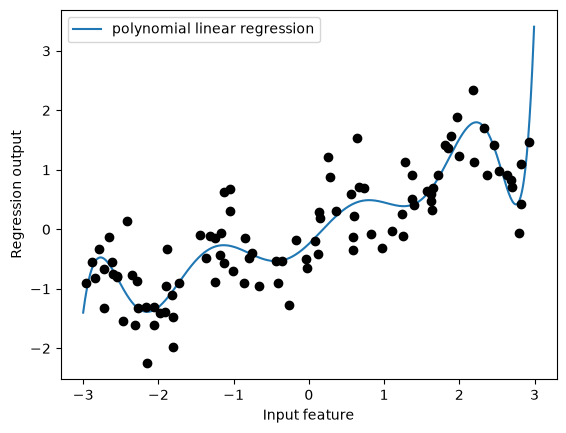

In [18]:
reg = LinearRegression().fit(X_poly, y)

line_poly = poly.transform(line)
plt.plot(line, reg.predict(line_poly), label='polynomial linear regression')
plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")
plt.show()

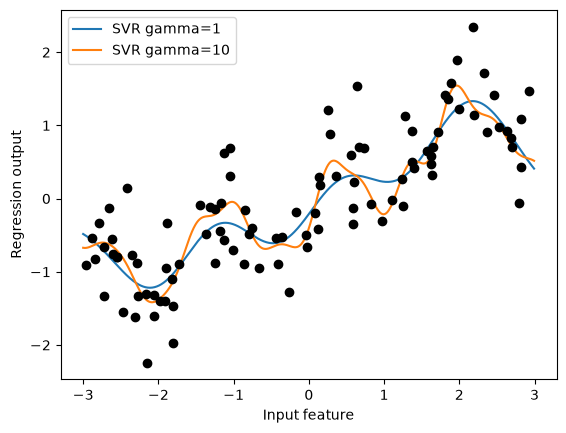

In [ ]:
#比較としてカーネル法を用いたSVMモデルを、変換していないオリジナルデータに適用してみる

from sklearn.svm import SVR

for gamma in [1, 10]:
    svr = SVR(gamma=gamma).fit(X, y)
    plt.plot(line, svr.predict(line), label='SVR gamma={}'.format(gamma))

plt.plot(X[:, 0], y, 'o', c='k')
plt.ylabel("Regression output")
plt.xlabel("Input feature")
plt.legend(loc="best")
plt.show()

**boston_housingに適用**

In [22]:
from sklearn.utils import Bunch
def load_boston():
    data_url = "http://lib.stat.cmu.edu/datasets/boston"
    raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)
    data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
    target = raw_df.values[1::2, 2]
    feature_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD',
        'TAX', 'PTRATIO', 'B', 'LSTAT']
    return Bunch(data=data, target=target, feature_names=np.array(feature_names))

<>:4: SyntaxWarning: invalid escape sequence '\s'
<>:4: SyntaxWarning: invalid escape sequence '\s'
C:\Users\seita\AppData\Local\Temp\ipykernel_12360\3973724285.py:4: SyntaxWarning: invalid escape sequence '\s'
  raw_df = pd.read_csv(data_url, sep="\s+", skiprows=22, header=None)


In [23]:
from sklearn.preprocessing import MinMaxScaler

boston = load_boston()
x_train, x_test, y_train, y_test = train_test_split(boston.data, boston.target, random_state=0)

#データのスケール変換
scaler = MinMaxScaler().fit(x_train)
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)

#二次までの多項式特徴量を作る
poly = PolynomialFeatures(degree=2).fit(x_train_scaled)
x_train_poly = poly.transform(x_train_scaled)
x_test_poly = poly.transform(x_test_scaled)

print("x_train_scaled.shape: {}".format(x_train_scaled.shape))
print("x_train_poly.shape: {}".format(x_train_poly.shape))

x_train_scaled.shape: (379, 13)
x_train_poly.shape: (379, 105)


In [24]:
print("Polynomial feature names:\n{}".format(poly.get_feature_names_out(boston.feature_names)))

Polynomial feature names:
['1' 'CRIM' 'ZN' 'INDUS' 'CHAS' 'NOX' 'RM' 'AGE' 'DIS' 'RAD' 'TAX'
 'PTRATIO' 'B' 'LSTAT' 'CRIM^2' 'CRIM ZN' 'CRIM INDUS' 'CRIM CHAS'
 'CRIM NOX' 'CRIM RM' 'CRIM AGE' 'CRIM DIS' 'CRIM RAD' 'CRIM TAX'
 'CRIM PTRATIO' 'CRIM B' 'CRIM LSTAT' 'ZN^2' 'ZN INDUS' 'ZN CHAS' 'ZN NOX'
 'ZN RM' 'ZN AGE' 'ZN DIS' 'ZN RAD' 'ZN TAX' 'ZN PTRATIO' 'ZN B'
 'ZN LSTAT' 'INDUS^2' 'INDUS CHAS' 'INDUS NOX' 'INDUS RM' 'INDUS AGE'
 'INDUS DIS' 'INDUS RAD' 'INDUS TAX' 'INDUS PTRATIO' 'INDUS B'
 'INDUS LSTAT' 'CHAS^2' 'CHAS NOX' 'CHAS RM' 'CHAS AGE' 'CHAS DIS'
 'CHAS RAD' 'CHAS TAX' 'CHAS PTRATIO' 'CHAS B' 'CHAS LSTAT' 'NOX^2'
 'NOX RM' 'NOX AGE' 'NOX DIS' 'NOX RAD' 'NOX TAX' 'NOX PTRATIO' 'NOX B'
 'NOX LSTAT' 'RM^2' 'RM AGE' 'RM DIS' 'RM RAD' 'RM TAX' 'RM PTRATIO'
 'RM B' 'RM LSTAT' 'AGE^2' 'AGE DIS' 'AGE RAD' 'AGE TAX' 'AGE PTRATIO'
 'AGE B' 'AGE LSTAT' 'DIS^2' 'DIS RAD' 'DIS TAX' 'DIS PTRATIO' 'DIS B'
 'DIS LSTAT' 'RAD^2' 'RAD TAX' 'RAD PTRATIO' 'RAD B' 'RAD LSTAT' 'TAX^2'
 'TAX PTRA

In [ ]:
#交互作用特徴量を入れた場合と入れなかった場合をリッジ回帰で比較
from sklearn.linear_model import Ridge

ridge = Ridge().fit(x_train_scaled, y_train)
print("Score without interaction: {:.3f}".format(ridge.score(x_test_scaled, y_test)))

ridge = Ridge().fit(x_train_poly, y_train)
print("Score with interaction: {:.3f}".format(ridge.score(x_test_poly, y_test)))


Score without interaction: 0.621
Score with interaction: 0.753


In [27]:
#ランダムフォレストでも同様に比較
from sklearn.ensemble import RandomForestRegressor

#ランダムフォレストはもともと特徴量同士の交互作用を自力で表現できる
#そのため似た情報・冗長な情報を持った特徴量が大量に追加され、スコアは悪化した

rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(x_train_scaled, y_train)
print("Score without interaction: {:.3f}".format(rf.score(x_test_scaled, y_test)))

rf = RandomForestRegressor(n_estimators=100, random_state=0).fit(x_train_poly, y_train)
print("Score with interaction: {:.3f}".format(rf.score(x_test_poly, y_test)))


Score without interaction: 0.797
Score with interaction: 0.776
